# Amazon Delivery Time Prediction — Version 03

**Improvements over V2 (RMSE ~40.99):**
1. **Haversine distance** — geographically correct distance on Earth's surface (V2 used broken Euclidean on lat/lon)
2. **Manhattan distance** — better proxy for urban grid routing
3. **Include Agent_Age, Agent_Rating, Category** — previously dropped columns
4. **Fix invalid (0,0) coordinates** — area-based imputation instead of leaving corrupted values
5. **Rich time features** — hour of day, rush hour flag, late-night flag, weekend flag
6. **No polynomial features** — removes dimensionality bloat; trees capture interactions natively
7. **sklearn GradientBoosting** instead of XGBoost — avoids libomp dependency crash
8. **Improved DNN** — wider (512), Swish activation, lower dropout
9. **4-model stacking ensemble** — RF + GradientBoosting + DNN + RidgeCV meta-learner

In [1]:
import pandas as pd
import numpy as np
import warnings
import random

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("All imports successful.")
print(f"TensorFlow version: {tf.__version__}")

All imports successful.
TensorFlow version: 2.20.0


In [2]:
file_path = "amazon_delivery.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Strip whitespace from categorical columns
for col in ['Weather', 'Traffic', 'Vehicle', 'Area']:
    df[col] = df[col].str.strip()

# Impute Agent_Rating with median (only ~54 missing)
median_rating = df['Agent_Rating'].median()
df['Agent_Rating'] = df['Agent_Rating'].fillna(median_rating)
print(f"\nImputed {df['Agent_Rating'].isnull().sum()} Agent_Rating values with median={median_rating}")

# Handle invalid (0,0) coordinates — these are sentinel/missing values
invalid_coords_mask = (df['Store_Latitude'] == 0.0) & (df['Store_Longitude'] == 0.0)
n_invalid = invalid_coords_mask.sum()
print(f"\nRows with invalid (0,0) coordinates: {n_invalid} ({n_invalid/len(df)*100:.1f}%)")

# Replace 0,0 with NaN
for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']:
    df.loc[invalid_coords_mask, col] = np.nan

# Impute with Area-group median
for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']:
    df[col] = df.groupby('Area')[col].transform(lambda x: x.fillna(x.median()))

# Handle negative latitudes (data quality issue spotted in row 92, 277)
df['Store_Latitude'] = df['Store_Latitude'].abs()

# Drop remaining NaN rows (Weather has ~91 missing)
rows_before = len(df)
df = df.dropna()
print(f"Dropped {rows_before - len(df)} rows with remaining NaN values")
print(f"Final dataset shape: {df.shape}")

Dataset shape: (43739, 16)

Missing values:
Agent_Rating    54
Weather         91
dtype: int64

Imputed 0 Agent_Rating values with median=4.7

Rows with invalid (0,0) coordinates: 3505 (8.0%)
Dropped 91 rows with remaining NaN values
Final dataset shape: (43648, 16)


In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance in km between two points on Earth."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def manhattan_distance_km(lat1, lon1, lat2, lon2):
    """Approximate Manhattan (L1) distance in km on Earth's surface."""
    R = 6371
    lat1_r, lon1_r, lat2_r, lon2_r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat_km = R * np.abs(lat2_r - lat1_r)
    avg_lat = (lat1_r + lat2_r) / 2
    dlon_km = R * np.cos(avg_lat) * np.abs(lon2_r - lon1_r)
    return dlat_km + dlon_km


# Distance features
df['Haversine_Distance'] = haversine_distance(
    df['Store_Latitude'], df['Store_Longitude'],
    df['Drop_Latitude'], df['Drop_Longitude']
)
df['Manhattan_Distance'] = manhattan_distance_km(
    df['Store_Latitude'], df['Store_Longitude'],
    df['Drop_Latitude'], df['Drop_Longitude']
)

# Time features
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Time_dt'] = pd.to_datetime(df['Order_Time'], format='%H:%M:%S')
df['Pickup_Time_dt'] = pd.to_datetime(df['Pickup_Time'], format='%H:%M:%S')

df['Day_of_Week'] = df['Order_Date'].dt.dayofweek
df['Order_Hour'] = df['Order_Time_dt'].dt.hour

df['Is_Rush_Hour'] = df['Order_Hour'].isin([8, 9, 10, 17, 18, 19, 20]).astype(int)
df['Is_Late_Night'] = df['Order_Hour'].isin([23, 0, 1, 2, 3, 4]).astype(int)
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)

# Time to pickup (minutes)
df['Time_To_Pickup'] = (df['Pickup_Time_dt'] - df['Order_Time_dt']).dt.total_seconds() / 60.0
# Handle midnight crossing (negative values)
df.loc[df['Time_To_Pickup'] < 0, 'Time_To_Pickup'] += 1440  # add 24 hours

# Label-encode Category (13 classes — too many for one-hot)
le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

# One-hot encode low-cardinality categoricals
df = pd.get_dummies(df, columns=['Weather', 'Traffic', 'Vehicle', 'Area'])

print("New features created:")
print("  - Haversine_Distance (km)")
print("  - Manhattan_Distance (km)")
print("  - Order_Hour, Is_Rush_Hour, Is_Late_Night, Is_Weekend")
print("  - Time_To_Pickup (minutes, midnight-aware)")
print("  - Category_Encoded (label-encoded)")
print("  - Agent_Age, Agent_Rating (now included)")
print(f"\nTotal columns: {df.shape[1]}")

New features created:
  - Haversine_Distance (km)
  - Manhattan_Distance (km)
  - Order_Hour, Is_Rush_Hour, Is_Late_Night, Is_Weekend
  - Time_To_Pickup (minutes, midnight-aware)
  - Category_Encoded (label-encoded)
  - Agent_Age, Agent_Rating (now included)

Total columns: 40


In [4]:
drop_cols = [
    'Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time',
    'Order_Time_dt', 'Pickup_Time_dt',
    'Delivery_Time', 'Category',
    'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude'
]

X = df.drop(columns=drop_cols)
y = df['Delivery_Time']

print(f"Feature matrix: {X.shape}")
print(f"\nFeatures ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Feature matrix: (43648, 28)

Features (28):
   1. Agent_Age
   2. Agent_Rating
   3. Haversine_Distance
   4. Manhattan_Distance
   5. Day_of_Week
   6. Order_Hour
   7. Is_Rush_Hour
   8. Is_Late_Night
   9. Is_Weekend
  10. Time_To_Pickup
  11. Category_Encoded
  12. Weather_Cloudy
  13. Weather_Fog
  14. Weather_Sandstorms
  15. Weather_Stormy
  16. Weather_Sunny
  17. Weather_Windy
  18. Traffic_High
  19. Traffic_Jam
  20. Traffic_Low
  21. Traffic_Medium
  22. Vehicle_motorcycle
  23. Vehicle_scooter
  24. Vehicle_van
  25. Area_Metropolitian
  26. Area_Other
  27. Area_Semi-Urban
  28. Area_Urban

Train: 34918 samples
Test:  8730 samples


In [5]:
print("=" * 60)
print("MODEL 1: RandomForest Regressor")
print("=" * 60)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

MODEL 1: RandomForest Regressor
RMSE: 23.5539
MAE:  18.0241
R²:   0.7957


In [6]:
print("\n" + "=" * 60)
print("MODEL 2: GradientBoosting (RandomizedSearchCV)")
print("=" * 60)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_leaf': [5, 10, 20]
}

gb = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

best_gb = random_search.best_estimator_
print(f"\nBest parameters: {random_search.best_params_}")

y_pred_gb = best_gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"RMSE: {rmse_gb:.4f}")
print(f"MAE:  {mae_gb:.4f}")
print(f"R²:   {r2_gb:.4f}")


MODEL 2: GradientBoosting (RandomizedSearchCV)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_leaf': 20, 'max_depth': 7, 'learning_rate': 0.05}
RMSE: 22.8381
MAE:  17.7141
R²:   0.8079



MODEL 3: Improved Deep Neural Network


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,233 (747.00 KB)

 Trainable params: 189,313 (739.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 11562.5430 - val_loss: 3622.0623 - learning_rate: 0.0010
Epoch 2/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1929.2509 - val_loss: 1367.2485 - learning_rate: 0.0010
Epoch 3/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1540.4349 - val_loss: 1289.4026 - learning_rate: 0.0010
Epoch 4/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1496.5414 - val_loss: 1271.6665 - learning_rate: 0.0010
Epoch 5/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1450.2101 - val_loss: 1191.5789 - learning_rate: 0.0010
Epoch 6/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1422.1771 - val_loss: 1112.6661 - learning_rate: 0.0010
Epoch 7/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1378.4121 - val_loss: 1039.1779 - learning_rate: 0.0010
Epoch 8/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1300.4576 - val_loss: 999.0236 - learning_rate: 0.0010
Epoch 9/150
873/873 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1

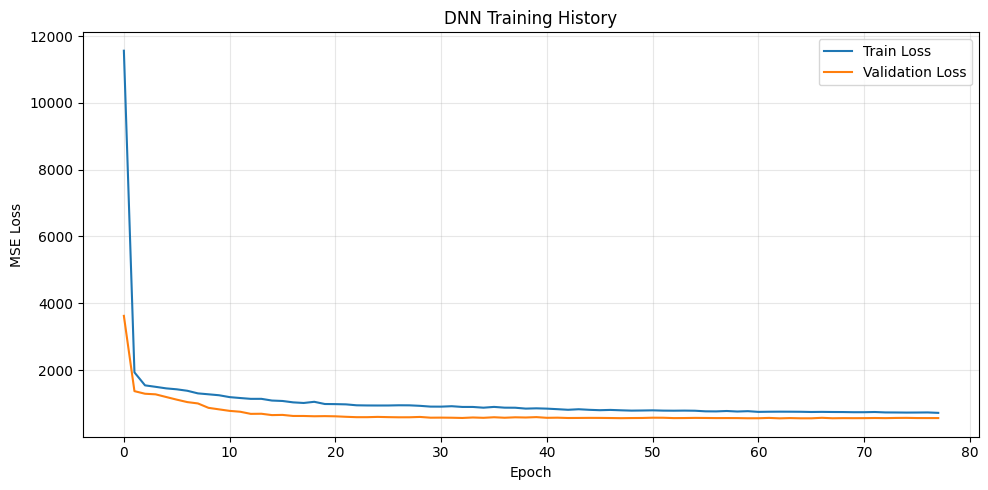

In [7]:
print("\n" + "=" * 60)
print("MODEL 3: Improved Deep Neural Network")
print("=" * 60)


def create_improved_dnn(input_dim):
    """Build a DNN with wider layers, Swish activation, and lower dropout."""
    model = Sequential()

    model.add(Dense(512, input_dim=input_dim, activation='swish',
                    kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(256, activation='swish', kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(128, activation='swish', kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(64, activation='swish', kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(1, activation='linear'))

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


dnn_model = create_improved_dnn(X_train_scaled.shape[1])
dnn_model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

y_pred_dnn = dnn_model.predict(X_test_scaled).flatten()
rmse_dnn = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
r2_dnn = r2_score(y_test, y_pred_dnn)

print(f"\nRMSE: {rmse_dnn:.4f}")
print(f"MAE:  {mae_dnn:.4f}")
print(f"R²:   {r2_dnn:.4f}")

# Training history plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print("\n" + "=" * 60)
print("MODEL 4: Stacking Ensemble (RF + GB + DNN)")
print("=" * 60)


class CustomDNNWrapper( RegressorMixin, BaseEstimator):
  """Sklearn-compatible wrapper for the Keras DNN model."""
    _estimator_type = 'regressor'

    def __init__(self, epochs=100, batch_size=32):
        self.epochs = epochs
        self.batch_size = batch_size
        self.model_ = None
        self.scaler_ = None

    def fit(self, X, y=None):
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)
        self.model_ = create_improved_dnn(X_scaled.shape[1])

        es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        self.model_.fit(
            X_scaled, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=0.2,
            callbacks=[es, rl],
            verbose=0
        )
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(X)
        return self.model_.predict(X_scaled, verbose=0).flatten()


dnn_wrapper = CustomDNNWrapper(epochs=100, batch_size=32)

estimators = [
    ('rf', RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5,
        n_jobs=-1, random_state=42
    )),
    ('gb', best_gb),
    ('dnn', dnn_wrapper)
]

stack_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    cv=3,
    n_jobs=1  # DNN is not fork-safe; use sequential
)

print("Fitting stacking model (this may take several minutes)...")
stack_reg.fit(X_train, y_train)

y_pred_stack = stack_reg.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae_stack = mean_absolute_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print(f"\nRMSE: {rmse_stack:.4f}")
print(f"MAE:  {mae_stack:.4f}")
print(f"R²:   {r2_stack:.4f}")


MODEL 4: Stacking Ensemble (RF + GB + DNN)
Fitting stacking model (this may take several minutes)...

RMSE: 22.7151
MAE:  17.5821
R²:   0.8100



MODEL COMPARISON
                      Model    RMSE     MAE     R2
V2 Baseline (DNN+XGB Stack) 40.9900     nan    nan
            V3 RandomForest 23.5539 18.0241 0.7957
        V3 GradientBoosting 22.8381 17.7141 0.8079
            V3 Improved DNN 23.8696 18.2578 0.7902
       V3 Stacking Ensemble 22.7151 17.5821 0.8100

BEST MODEL: V3 Stacking Ensemble
RMSE: 22.7151
Improvement over V2: 44.6%


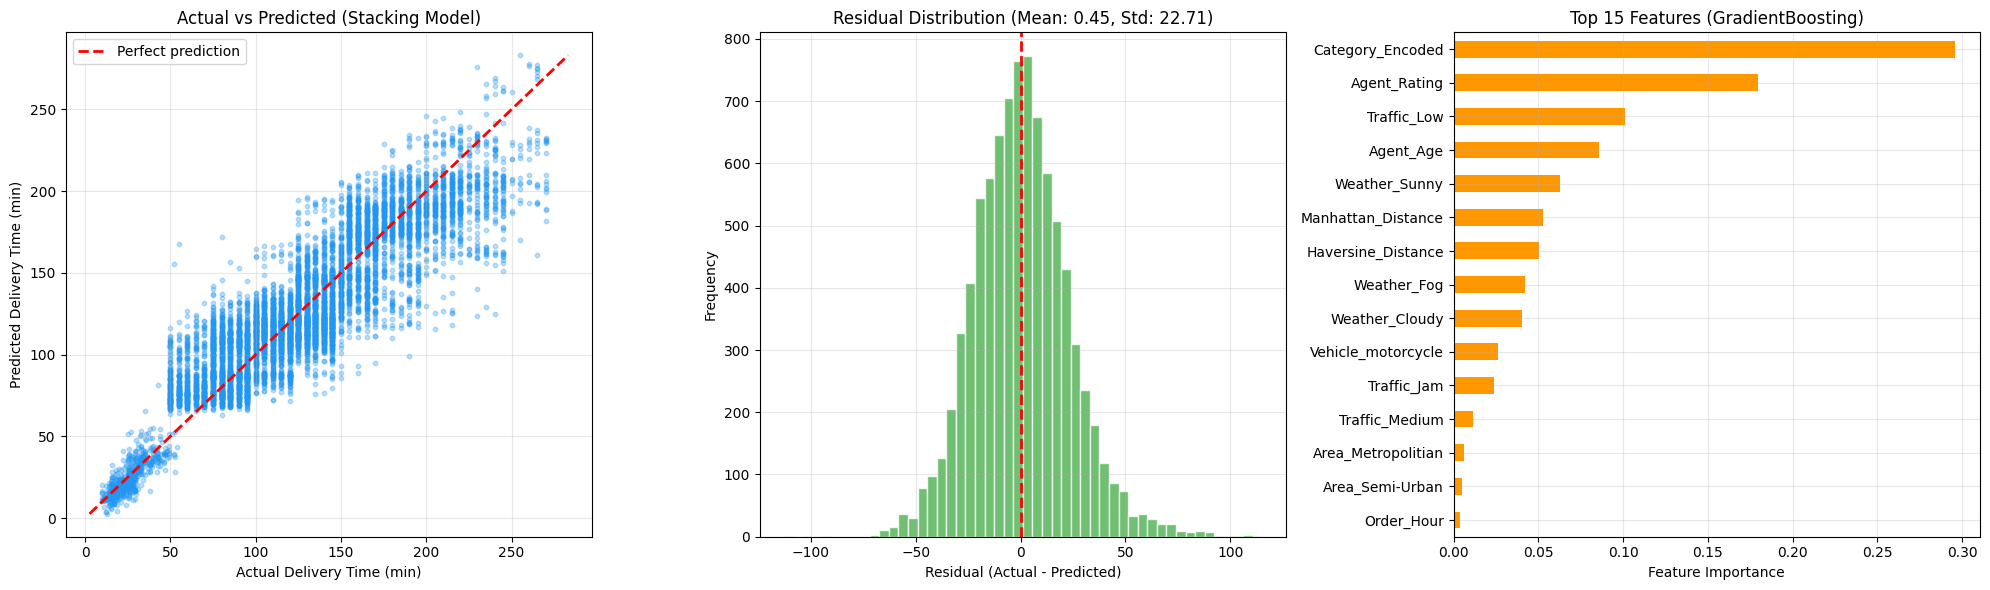


Sample Prediction:
  Predicted Delivery Time: 100.90 minutes
  Actual Delivery Time:    150.00 minutes
  Error:                   49.10 minutes


In [10]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results = pd.DataFrame({
    'Model': [
        'V2 Baseline (DNN+XGB Stack)',
        'V3 RandomForest',
        'V3 GradientBoosting',
        'V3 Improved DNN',
        'V3 Stacking Ensemble'
    ],
    'RMSE': [40.99, rmse_rf, rmse_gb, rmse_dnn, rmse_stack],
    'MAE': [None, mae_rf, mae_gb, mae_dnn, mae_stack],
    'R2': [None, r2_rf, r2_gb, r2_dnn, r2_stack]
})

# Format for display
display_df = results.copy()
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f"{x:.4f}")
display_df['MAE'] = display_df['MAE'].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")
display_df['R2'] = display_df['R2'].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")
print(display_df.to_string(index=False))

# Best model
best_idx = results['RMSE'].idxmin()
best_model_name = results.loc[best_idx, 'Model']
best_rmse = results.loc[best_idx, 'RMSE']
improvement = ((40.99 - best_rmse) / 40.99) * 100

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"RMSE: {best_rmse:.4f}")
print(f"Improvement over V2: {improvement:.1f}%")
print(f"{'='*60}")

# --- Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_stack, alpha=0.3, s=10, c='#2196F3')
min_val = min(y_test.min(), y_pred_stack.min())
max_val = max(y_test.max(), y_pred_stack.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Delivery Time (min)')
axes[0].set_ylabel('Predicted Delivery Time (min)')
axes[0].set_title('Actual vs Predicted (Stacking Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual distribution
residuals = y_test.values - y_pred_stack
axes[1].hist(residuals, bins=50, edgecolor='white', color='#4CAF50', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f})')
axes[1].grid(True, alpha=0.3)

# 3. Feature importance (GradientBoosting)
feature_imp = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=True)
top_15 = feature_imp.tail(15)
top_15.plot(kind='barh', ax=axes[2], color='#FF9800')
axes[2].set_xlabel('Feature Importance')
axes[2].set_title('Top 15 Features (GradientBoosting)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Sample Prediction ---
random_index = random.randint(0, len(X_test) - 1)
sample_features = X_test.iloc[random_index:random_index + 1]
actual = y_test.iloc[random_index]
predicted = stack_reg.predict(sample_features)[0]

print(f"\nSample Prediction:")
print(f"  Predicted Delivery Time: {predicted:.2f} minutes")
print(f"  Actual Delivery Time:    {actual:.2f} minutes")
print(f"  Error:                   {abs(actual - predicted):.2f} minutes")